Gradient Descent Exercise
We model miles per gallon mpg based on weight wt for the mtcars data and use gradient descent to find the slope coefficient.

We are only fitting slope and not intercept, so we betaill center the data and fit the model

$$ mpg = \beta \times wt $$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
cars = pd.read_csv('../data/cars.csv')

cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [5]:
X = cars[['wt']]
y = cars[['mpg']]

Text(0.5, 1.0, 'Scatterplot of mpg vs wt')

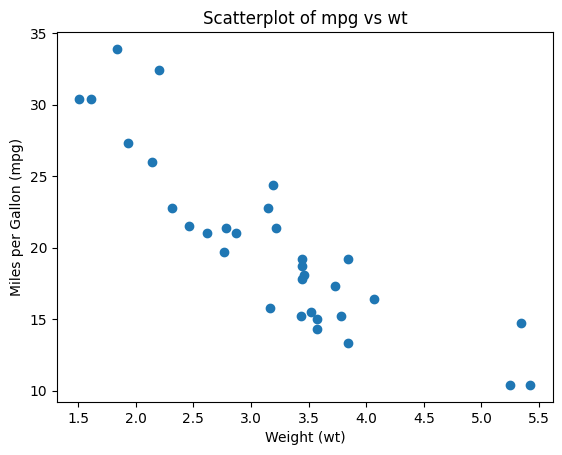

In [6]:
plt.scatter(cars['wt'], cars['mpg'])
plt.xlabel('Weight (wt)')
plt.ylabel('Miles per Gallon (mpg)')
plt.title('Scatterplot of mpg vs wt')

We are only fitting slope and not intercept, so we will center the data.

Remark:
Note that here we center both x and y for the purposes of illustrating gradient descent for a simple no-intercept univariate example, as the regression line necessarily will pass through the origin. But while fixed transformations of the target are not uncommon; for example log transformation, we will for the most part never center or scale the target. Indeed, in most cases we are predicting the target, so cant subtract the mean for data we dont have!

Text(0, 0.5, 'Centered mpg')

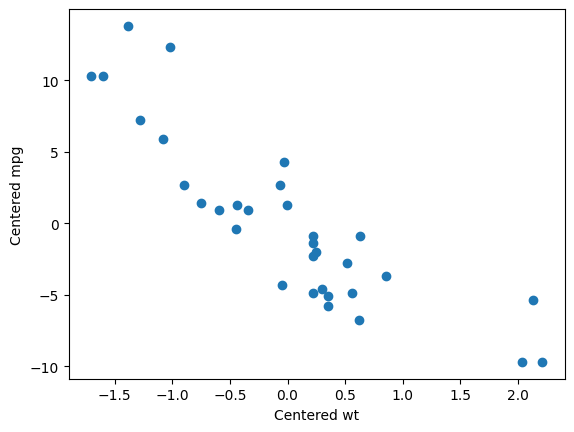

In [7]:
Xcent = X - X.mean()
ycent = y - y.mean()

plt.scatter(Xcent, ycent)
plt.xlabel('Centered wt')
plt.ylabel('Centered mpg')

Loss function MSE
The mean square error is simply the SSE/n. We will denote the loss as $J$ as is consistent with machine learning conventions. MSE is much nicer - both mathematically and computationally - than RMSE. We are intersted in minimizing the error, and both are minimized by the same $\beta$ so we use the MSE for training models.

$$ \begin{aligned} J(\beta) &= \frac{1}{n}\sum_{i=1} ^n (y^{(i)} - \hat{y}^{(i)})^2 \\ &= \frac{1}{n}\sum_{i=1} ^n (y^{(i)} - \beta \, wt^{(i)})^2 \end{aligned} $$

with derivative

$$ \frac{d J}{d \beta} = -\frac{2}{n} \sum_{i=1} ^n (y^{(i)} - \beta \, wt^{(i)}) wt $$

We can write the above in matrix form. We dont need this here, but this generalizes to the multivariate case, where $\beta$ is a vector, which we will see soon enough.

$$ J(\beta) = \frac{1}{n} ({\bf {Y}} - {\bf X} \beta)^T \ ({\bf {Y}} - {\bf X} \beta) $$

With derivative

$$ \frac{\partial J}{\partial \beta} = -\frac{2}{n} {\bf X}^T ({\bf {Y}} - {\bf X} \beta) $$

We use partial derivative $\partial$ notation here, which comes into play in the multivariate case. But here, the partial is just the derivative with respect to the single variable $\beta$.

Now define helper functions
We wont define classes here, just functions will do. Note that Xcent and y are data frames. In order to do the element wise multiplication X*beta, we only want the values. Later, with multiple predictors and and coefficient vector $\beta$, We will do a matrix multiplication, which vectorizes the multiplication of predictor values times coefficients for each row.

In [8]:
Xvals = Xcent.values
yvals = ycent.values

In [9]:
def get_loss(beta, X, y):
    return np.sum((y - X*beta)**2) / len(y)

Check this

In [10]:
get_loss(0.5, Xvals, yvals  )

np.float64(40.377628109374996)

In [11]:
def get_gradient(beta, X, y):
    grad = -2 * np.sum(X * (y - X*beta)) / len(y)
    return grad

In [12]:
get_gradient(0.5, Xvals, yvals)

np.float64(10.841037437499999)

In [13]:
grad = get_gradient(0.5, Xvals, yvals)
get_loss(grad, Xvals, yvals)

np.float64(251.66513697531633)

In [14]:
beta = np.random.normal(loc=0.0, scale=0.01, size= 1)

get_loss(beta, Xvals, yvals)

np.float64(35.12386434116851)

In [15]:
def perform_gradient_descent(X, y, eta, num_iters):

    #initial value of beta. We keep track and append; hence the []
    
    beta_init = np.random.normal(loc=0.0, scale=0.01, size=1)   
    beta = np.array([beta_init])
    
    loss_init = get_loss(beta_init, X, y)
    loss = np.array([loss_init])


    #for a fixed number of iterations
    for i in range(num_iters):
        grad = get_gradient(beta[-1], X, y)

        #travel in the direction opposite the gradient
        beta_new = beta[-1] - eta*grad
        loss_new = get_loss(beta_new, X, y)

        beta = np.append(beta, beta_new)
        loss = np.append(loss, loss_new)
        
    return beta, loss 

In [16]:
beta_vals, loss = perform_gradient_descent(Xvals, yvals, 0.01, 200)

Text(0.5, 1.0, 'Final beta: -5.22')

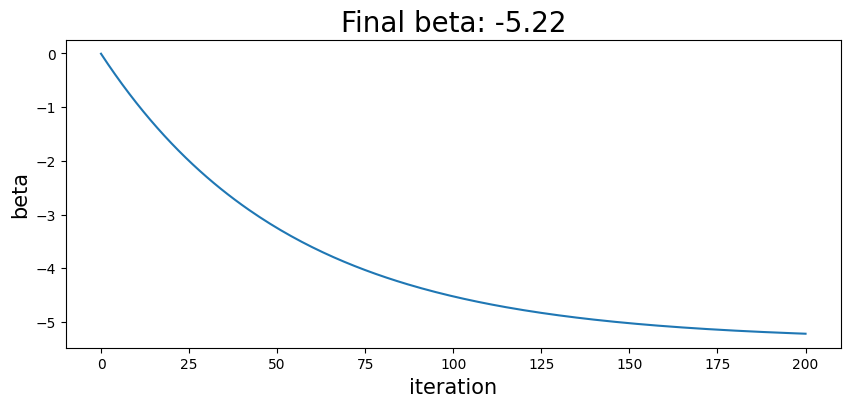

In [17]:
plt.figure(figsize=(10,4))
plt.plot(beta_vals)
plt.xlabel('iteration', fontsize=15)
plt.ylabel('beta', fontsize=15)
plt.title('Final beta: %s'%np.round(beta_vals[-1].item(),2), fontsize=20)

Text(0.5, 1.0, 'Final loss: 8.71')

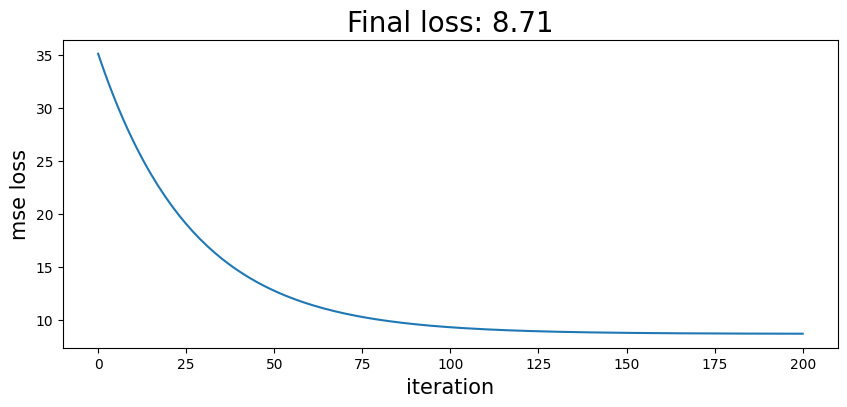

In [18]:
plt.figure(figsize=(10,4))
plt.plot(loss)
plt.xlabel('iteration', fontsize=15)
plt.ylabel('mse loss', fontsize=15)
plt.title('Final loss: %s'%round(loss[-1],2), fontsize=20)

Check the fit visually

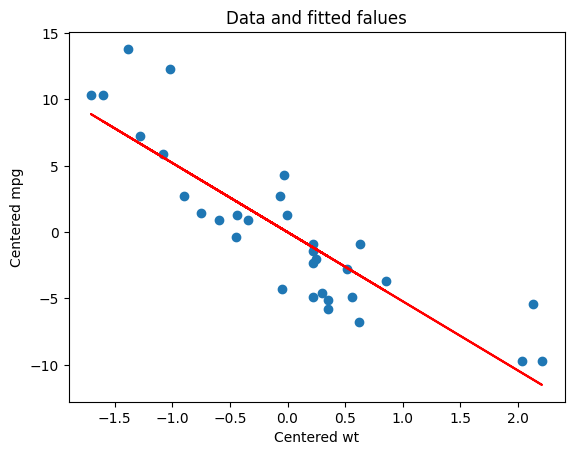

In [19]:
beta = beta_vals[-1]
preds = beta * Xvals

plt.scatter(Xvals[:, 0], yvals[:, 0])
plt.plot(Xvals[:, 0], preds[:, 0], color='red')
plt.xlabel('Centered wt')
plt.ylabel('Centered mpg')
plt.title('Data and fitted falues')
plt.show()

Now try scaling

In [20]:
from sklearn.preprocessing import StandardScaler

Xvals = StandardScaler().fit_transform(cars[['wt']])
yvals = StandardScaler().fit_transform(cars[['mpg']])

Text(0.5, 1.0, 'Scaled final beta: -0.85')

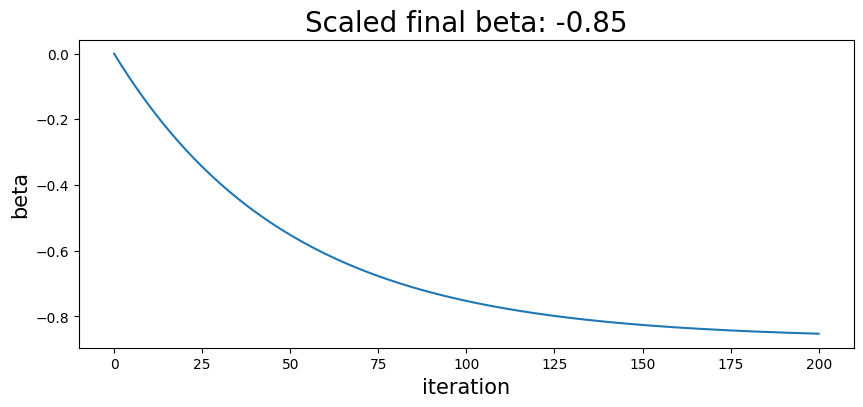

In [21]:
beta_vals, loss = perform_gradient_descent(Xvals, yvals, 0.01, 200)

plt.figure(figsize=(10,4))
plt.plot(beta_vals)
plt.xlabel('iteration', fontsize=15)
plt.ylabel('beta', fontsize=15)
plt.title('Scaled final beta: %s'%np.round(beta_vals[-1].item(),2), fontsize=20)

Text(0.5, 1.0, 'Scaled final loss: 0.25')

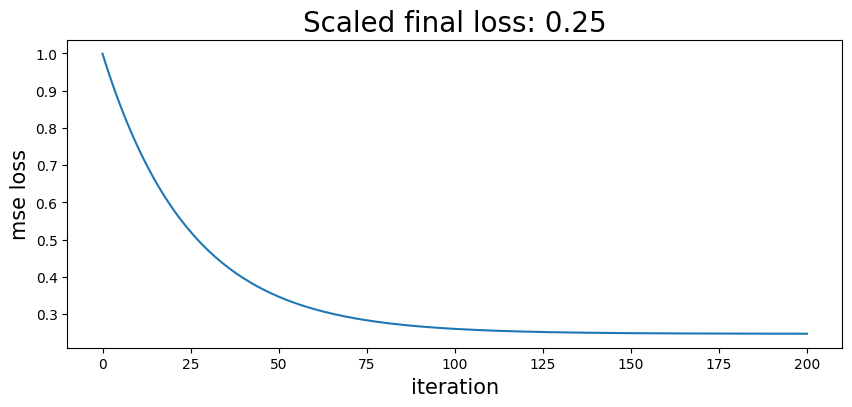

In [22]:
plt.figure(figsize=(10,4))
plt.plot(loss)
plt.xlabel('iteration', fontsize=15)
plt.ylabel('mse loss', fontsize=15)
plt.title('Scaled final loss: %s'%round(loss[-1],2), fontsize=20)

Check the fit visually

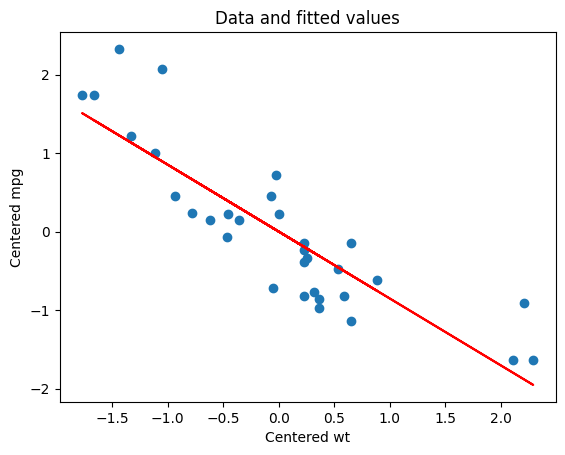

In [23]:
beta = beta_vals[-1]
preds = beta * Xvals

plt.scatter(Xvals[:, 0], yvals[:, 0])
plt.plot(Xvals[:, 0], preds[:, 0], color='red')
plt.xlabel('Centered wt')
plt.ylabel('Centered mpg')
plt.title('Data and fitted values')
plt.show()

Exercise:
Define a predict function. This function returns the vector of predictions - the sum of the products of the coefficients times the predictor values.
Use your predict function to find the RMSE of your model.


In [24]:
def predict(beta, X):
    """Returns the vector of predictions by computing the dot product of X and beta."""
    return np.dot(X, beta)

def calculate_rmse(beta, X, y):
    """Calculates the Root Mean Squared Error (RMSE) using the model predictions."""
    predictions = predict(beta, X)
    return np.sqrt(np.mean((y - predictions) ** 2))

In [26]:
predictions = predict(beta_vals[-1], Xvals)
rmse = calculate_rmse(beta_vals[-1], Xvals, yvals)

In [ ]:
print(rmse)

0.49739304258710987


In [31]:
print("Minimum:", yvals.min())
print("Maximum:", yvals.max())

Minimum: -1.6336103713847328
Maximum: 2.3279342893096193


In [33]:
print(cars.describe())

             mpg        cyl        disp          hp       drat         wt  \
count  32.000000  32.000000   32.000000   32.000000  32.000000  32.000000   
mean   20.090625   6.187500  230.721875  146.687500   3.596563   3.217250   
std     6.026948   1.785922  123.938694   68.562868   0.534679   0.978457   
min    10.400000   4.000000   71.100000   52.000000   2.760000   1.513000   
25%    15.425000   4.000000  120.825000   96.500000   3.080000   2.581250   
50%    19.200000   6.000000  196.300000  123.000000   3.695000   3.325000   
75%    22.800000   8.000000  326.000000  180.000000   3.920000   3.610000   
max    33.900000   8.000000  472.000000  335.000000   4.930000   5.424000   

            qsec         vs         am       gear     carb  
count  32.000000  32.000000  32.000000  32.000000  32.0000  
mean   17.848750   0.437500   0.406250   3.687500   2.8125  
std     1.786943   0.504016   0.498991   0.737804   1.6152  
min    14.500000   0.000000   0.000000   3.000000   1.0000  
2